<a href="https://colab.research.google.com/github/Eduardo-roda/Backend/blob/SEMANA01/20250610_Regresi%C3%B3n_Polin%C3%B3mica_Simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importar librería
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
dataset = pd.read_csv('Salarios.csv')
x = dataset.iloc[ : , 1: 2 ].values
y = dataset.iloc[ : , -1].values

In [5]:
# train_test_split: divide el dataset en 4 variables
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
x_train = np.sort(x_train, axis = 0)
y_train = np.sort(y_train , axis = None)

x_test = np.sort(x_test, axis = 0)
y_test = np.sort(y_test , axis = None)

In [6]:
#Ajustar la regreción polinoomial con el dataset
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 3)
x_poly = poly_reg.fit_transform(x_train)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(x_poly, y_train)

LinearRegression()

In [8]:
# Predecir el arreglo x_train
ypred_train = lin_reg_2.predict(poly_reg.fit_transform(x_train))
ypred_train

array([  26073.85372045,   72038.39441535,   80448.04061558,
         73165.00079327,   98969.6969697 ,  324350.15072188,
        566536.80786927,  924204.02982707, 1419214.02506743])

In [16]:
# Predecir el arreglo x_test
ypred_test = lin_reg_2.predict(poly_reg.fit_transform(x_test))
ypred_test

array([  72051.48342059,  175781.84991274, 2073429.00206251])

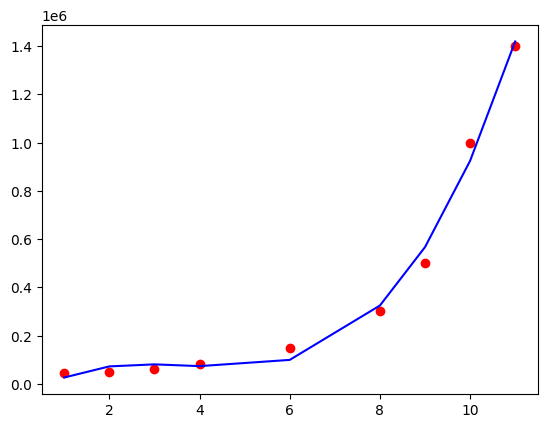

In [11]:
plt.scatter(x_train, y_train, color="red")
plt.plot(x_train, lin_reg_2.predict(poly_reg.fit_transform(x_train)), color="blue")

In [15]:
# MÉTRICAS
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print("R2:   ", r2_score(y_test, ypred_test))
print("MAE:  ", mean_absolute_error(y_test, ypred_test))
print("MSE:  ", mean_squared_error(y_test, ypred_test))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, ypred_test)))

R2:    0.9575292054829504
MAE:   111865.22290972601
MSE:   25596675957.70897
RMSE:  159989.61203062205
